In [1]:
import scipy
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)
subject = ['01TG', '02ES', '03AC', '04AB', '06KK', '07TS', '10AS', '11AK',
       '13AU', '14BE', '15AZ', '18KK', '19VB', '20EC', '21EC', '22ES',
       '23MM', '24EK', '25PP']

In [5]:
order = np.array('1 2 1 2 1 1 2 2 1 2 2 1 2 2 1 1 2 1 1'.split(' ')).astype(int)
orders = dict(zip(subject, order))

def define_order(df, order):
    order_diskl = {1: 'QM', 2: 'IM'}
    df['order'] = -1
    for subject in df.subject.unique():
        first_order = order_diskl[order[subject]]
        second_order = 'QM' if first_order == 'IM' else 'IM'
        df.loc[(df.subject == subject) & (df.condition == first_order), 'order'] = 1
        df.loc[(df.subject == subject) & (df.condition == second_order), 'order'] = 2
    return df

df = define_order(df, orders)

# game-game correlations

In [ ]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "MI"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]
metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']

<Axes: >

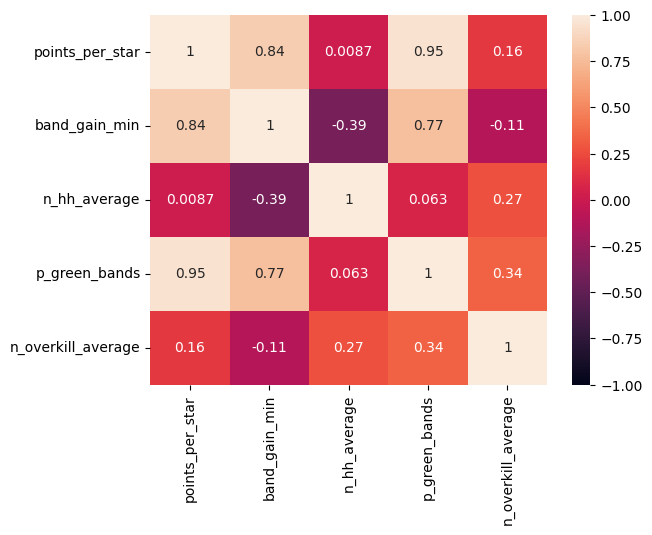

In [13]:
df_corr = df[metrics].corr()
sns.heatmap(df_corr, annot=True, vmin=-1, vmax=1)

In [44]:
metrics = ['p_good_steps', 'p_green_steps']
# metrics = ['vel_good_all', 'p_good_steps']
# metrics = ['green_steps_min', 'p_good_steps']
for mode in ['im', 'qm']:
    print(f'---{mode}---')
    for game in [1, 2, 3]:
        value_2 = df.loc[(df['mode'] == mode) & (df.n_game == game)][metrics[0]].values
        value_1 = df.loc[(df['mode'] == mode) & (df.n_game == game)][metrics[1]].values
        stat = scipy.stats.pearsonr(value_1, value_2)
        decision = 'YES' if stat[1] < .05 else 'NO'
        print(f'Game {game}: r={stat[0].round(3)}, p={stat[1].round(5)}')

---im---
Game 1: r=0.857, p=0.00152
Game 2: r=0.713, p=0.02061
Game 3: r=0.563, p=0.09002
---qm---
Game 1: r=0.959, p=1e-05
Game 2: r=0.906, p=0.00031
Game 3: r=0.835, p=0.00262


# game - survey

In [25]:
filename = r'..\data\results\game_metrics_per_n_game.csv'
df = pd.read_csv(filename)
df.loc[df.condition == 'im', 'condition'] = "MI"
df.loc[df.condition == 'qm', 'condition'] = "QM"
df = define_order(df, orders)
# Исключаем 04АВ, т.к. у него не записана последняя игра (3) в режиме QM к большому сожалению... 
# Исключаем 24EK, т.к. там сильно всё плохо в одном из режимов. 
df = df.loc[~df.subject.isin(['04AB', '24EK'])]
game_metrics = ['points_per_star', 'band_gain_min', 'n_hh_average', 'p_green_bands', 'n_overkill_average']

In [23]:
filename = r'..\data\results\questionario.xlsx'
df_surv = pd.read_excel(filename) 
df_surv = df_surv.loc[~df_surv.subject.isin(['04AB', '24EK'])]

In [24]:
df_surv

,subject,condition,n,attention,Difficulty,Success,TaskFit,TaskOrScreen,Auto
0,01TG,QM,1,0.159259,0.766667,0.862963,0.000000,0.000000,0.000000
1,02ES,QM,1,0.035185,0.514815,0.611111,0.000000,0.000000,0.000000
2,03AC,QM,1,0.253704,0.359259,0.803704,0.000000,0.000000,0.000000
4,06KK,QM,1,0.372222,0.270370,0.738889,0.000000,0.000000,0.000000
5,07TS,QM,1,0.296296,0.362963,0.585185,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
103,20EC,MI,3,0.605556,0.553704,0.561111,0.968519,0.500000,0.470370
104,21EC,MI,3,0.679630,0.537037,0.492593,0.635185,0.672222,0.675926
105,22ES,MI,3,0.848148,0.451852,0.703704,0.629630,0.811111,0.105556
106,23MM,MI,3,0.400000,0.483333,0.420370,0.833333,0.838889,0.890741


In [ ]:
surv_metrics = ['Success', 'Difficulty', 'attention'] #['QuasiAuto', 'ImagAuto']
for mode in ['MI', 'QM']:
    print(f'---Mode {mode}---')
    for metric_1 in surv_metrics:
        for metric_2 in game_metrics:
            value_2 = df.loc[(df['condition'] == mode) ][metric_2].values
            value_1 = df_surv.loc[(df_surv['condition'] == mode) ][f'{metric_1}'].values
            stat = scipy.stats.pearsonr(value_1, value_2)
            decision = 'YES' if stat[1] < .05 else 'NO'
            if decision == 'YES':
                print(f'{metric_1}--vs--{metric_2}: r={stat[0].round(2)}, p={stat[1].round(5)} ------- {decision}!')

---Mode MI---
Success--vs--points_per_star: r=0.31, p=0.02746 ------- YES!
Success--vs--p_green_bands: r=0.37, p=0.00827 ------- YES!
attention--vs--p_green_bands: r=0.31, p=0.025 ------- YES!
---Mode QM---
Difficulty--vs--n_overkill_average: r=0.42, p=0.00201 ------- YES!


In [ ]:
surv_metrics = ['Success', 'Difficulty', 'attention', 'TaskOrScreen'] #['QuasiAuto', 'ImagAuto']
game_metrics = ['total_score', 'p_green_steps', 'n_hh_average', 'n_overkill_average']
for mode in ['im', 'qm']:
    print(f'---Mode {mode}---')
    for metric_1 in surv_metrics:
        for metric_2 in game_metrics:
            value_2 = df_av.loc[(df_av['mode'] == mode)][metric_2].values
            value_1 = df_surv.loc[(df_surv['mode'] == mode)][metric_1].values
            stat = scipy.stats.pearsonr(value_1, value_2)
            decision = 'YES' if stat[1] < .05 else 'NO'
            print(f'{metric_1}--vs--{metric_2}: r={stat[0].round(2)}, p={stat[1].round(5)} ------- {decision}!')

---Mode im---
TaskOrScreen--vs--total_score: r=-0.38, p=0.28434 ------- NO!
TaskOrScreen--vs--p_green_steps: r=-0.25, p=0.48126 ------- NO!
TaskOrScreen--vs--n_hh_average: r=0.43, p=0.21101 ------- NO!
TaskOrScreen--vs--n_overkill_average: r=-0.18, p=0.6191 ------- NO!
---Mode qm---
TaskOrScreen--vs--total_score: r=0.23, p=0.52844 ------- NO!
TaskOrScreen--vs--p_green_steps: r=0.25, p=0.47987 ------- NO!
TaskOrScreen--vs--n_hh_average: r=-0.24, p=0.50844 ------- NO!
TaskOrScreen--vs--n_overkill_average: r=0.21, p=0.55506 ------- NO!


In [22]:
df_av

,total_score,available_points,relative_score,game_duration,score_min,score_sec,green_steps_min,p_green_steps,p_good_steps,aver_time,n_hh,n,hh_percent,n_hh_average,n_overkill_average,n_game,absolute_score,subject,mode
0,3484.67,5748.67,60.59,5.31,660.54,11.01,21.35,84.12,67.62,10.82,3.67,23.67,15.25,0.18,0.82,2.0,10454.0,01TG,im
1,4089.67,6063.67,67.38,6.58,637.39,10.62,19.47,91.71,73.29,13.98,11.00,31.00,33.17,0.55,0.88,2.0,12269.0,01TG,qm
2,4165.33,5511.33,75.61,5.31,790.00,13.17,24.04,90.08,80.38,10.37,3.67,23.67,14.58,0.18,0.35,2.0,12496.0,02ES,im
3,3766.00,5674.00,66.06,8.61,469.70,7.83,14.57,85.41,73.33,17.12,20.00,40.00,47.42,1.00,0.65,2.0,11298.0,02ES,qm
4,3401.67,6211.67,54.81,5.30,643.29,10.72,22.03,88.71,62.48,10.58,1.33,21.33,5.93,0.07,1.77,2.0,10205.0,03AC,im
5,3751.67,6161.67,60.90,5.72,657.38,10.96,21.22,92.18,69.29,11.70,5.00,25.00,19.92,0.25,1.23,2.0,11255.0,03AC,qm
6,3446.67,6256.67,54.67,8.32,423.55,7.06,14.53,83.99,65.89,16.60,17.00,37.00,41.48,0.85,1.30,2.0,10340.0,06KK,im
7,2848.00,5772.00,49.19,6.89,428.87,7.15,17.04,81.89,64.84,13.00,8.33,28.33,26.49,0.42,1.24,2.0,8544.0,06KK,qm
8,3230.33,5586.33,57.12,10.39,321.95,5.37,11.51,83.93,70.63,21.72,31.00,51.00,60.10,1.55,0.60,2.0,9691.0,07TS,im
9,3572.67,5660.67,63.30,9.36,397.81,6.63,13.25,84.65,73.93,18.50,23.67,43.67,52.54,1.18,0.48,2.0,10718.0,07TS,qm
